# はじめに
半年間、データ分析を学習した。学んだ技術を活かして、予測を行い、結果をまとめた。

本レポートでは、岡山市が公開する人流オープンデータを用い、エリアごとの人流動向の違いとその時系列的特徴を分析することを目的とする。中心市街地、再開発地域、住宅地、郊外商業地、地域拠点といった性格の異なるエリアによって、人流パターンに差異が生じると考えられるが、その違いを定量的に示したい。

本レポートでは、岡山市内の5地域（中心部、北長瀬、原・原尾島、岡南、西大寺）を対象に人流データを用いた分析を行い、都市機能の違いが人流動向にどのような影響を与えているのかを明らかにする。

本分析では、以下の仮説を設定した。
* **仮説1**: 中心部は商業・業務機能の集中により、滞在人口が多い。
* **仮説2**: 岡南地域は郊外型商業地として、滞在人口が一定で推移する。
* **仮説3**: 西大寺は周辺を住宅地が囲む地域拠点である特徴から滞在人口が一定で推移する。
* **仮説4**: 浜・原尾島は住宅地としての性格が強く、人流の変動が比較的小さい。
* **仮説5**: 北長瀬は近年の再開発および商業施設の集積により、人流が増加傾向。

これらの仮説を検証するため、時系列分解および予測モデルを用いた分析を行う。

# 分析するデータ
## 用いたデータについて
本分析では、岡山市が公式に公開している人流データのオープンデータを使用した。データは岡山市公式ウェブサイトよりCSV形式で取得し、公開されているデータ定義および留意事項を確認した上で利用している。

## データ定義・留意点
* データは携帯端末の位置情報等をもとにした**推計値**であり、実測値ではない
* **個人を特定できないよう匿名化・集計処理**が施されている
* 特定の個人や端末の移動履歴は含まれず、地域単位での傾向把握を目的としたデータである
* 単位や集計方法（人数は概数、一定単位で丸め処理）が定義されている

## データの内容（簡潔な整理）
* **対象期間** :2018年1月 〜 2025年4月
* **集計頻度** :月次
* **主な項目** :
  * 人流（滞在人口・通行人口の推計値）
  * 属性別集計（性別、年代）
  * 平日／祝休日別集計
* **データ形式** :CSV形式（時系列データ）
* **対象エリア** :
  * 中心市街地
  * 岡南
  * 西大寺
  * 浜・原尾島
  * 北長瀬
  
これらのエリアはいずれも岡山市の都心部またはその周辺に位置しており、商業拠点、交通結節点、住宅地など異なる機能を持つ地域である。そのため、人流の時間的変化や季節性に地域差が表れやすいと考えられる。


# 実行環境
* 開発環境 :Google Coraboratory
* 言語 :Python
* ライブラリ :Matplotlib、prophet、plotly、pandas、numpy、seaborn、statsmodels

# 分析手順
1. 前処理
目的変数の作成: 休日の男性数＋女性数
カラム名変更: Prophetモデルを使用するためカラム名をds（日付）、y（目的変数）に変更
2. STL分解
各地域のデータをトレンド・季節性・残差に分解
3. 予測
Prophetモデルを使用して、直近の12時点の人流を予測
学習データ: 2018/1~2024/4
テストデータ: 2024/5~2025/4

# 各地域の分析

## 必要なライブラリをimport

In [90]:
!pip install matplotlib
!pip install matplotlib seaborn

In [91]:
!pip install japanize-matplotlib

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import japanize_matplotlib
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error

## 各地域の前処理

* 岡山駅周辺部のデータ 'area1_month.csv'
* 岡南地域のデータ 'kounan_month.csv'
* 西大寺地域のデータ 'saidaiji_month.csv'  
* 浜・原尾島地域のデータ 'hama_haraojima_month.csv'
* 北長瀬地域のデータ 'kitanagase_month.csv'

### `center_df` の前処理

In [93]:

# center_df の前処理
center_df = pd.read_csv('area1_month.csv', encoding="cp932", header=1)
center_df.head()

,Unnamed: 0,Unnamed: 1,男性,女性,20代,30代,40代,50代,60代,70歳以上,...,Unnamed: 20,Unnamed: 21,男性.2,女性.2,20代.2,30代.2,40代.2,50代.2,60代.2,70歳以上.2
0,2018年1月,期間全体,2532.8,2611.6,880.7,768.9,904.5,797.8,826.2,966.3,...,NaN,祝休日,741.6,817.5,279.3,241.4,262.2,234.1,244.6,297.5
1,2018年2月,期間全体,2331.5,2388.7,829.0,688.6,828.4,738.4,749.8,886.0,...,NaN,祝休日,705.0,801.8,294.3,228.6,253.9,230.8,221.7,277.4
2,2018年3月,期間全体,2735.1,2754.3,953.2,810.7,956.0,848.9,878.7,1041.9,...,NaN,祝休日,832.1,923.6,322.4,272.4,301.2,264.5,262.2,332.9
3,2018年4月,期間全体,2599.5,2655.0,908.6,785.5,879.2,783.7,820.7,1076.8,...,NaN,祝休日,834.9,930.4,336.9,278.1,289.2,254.1,262.2,344.7
4,2018年5月,期間全体,2681.5,2722.5,988.5,812.1,895.5,814.2,821.8,1071.9,...,NaN,祝休日,846.1,951.5,372.0,273.0,286.6,259.4,259.4,347.2


In [94]:
center_df = center_df.rename(columns={'Unnamed: 0': 'ds'})
# .strアクセサーを使用する前に、'ds'が文字列型であることを確認
center_df['ds'] = pd.to_datetime(center_df['ds'], format='%Y年%m月')
center_df['y'] = center_df['男性.2'] + center_df['女性.2']

# 必要なカラムを取り出す
columns = ['ds','y']

center_df = center_df[columns]
center_df.head()

,ds,y
0,2018-01-01,1559.1
1,2018-02-01,1506.8
2,2018-03-01,1755.7
3,2018-04-01,1765.3
4,2018-05-01,1797.6


### `kounan_df` の前処理

In [95]:
# kounan_df の前処理
kounan_df = pd.read_csv('kounan_month.csv', encoding="cp932", header=1)
kounan_df.head()

,岡南,Unnamed: 1,男性,女性,20代,30代,40代,50代,60代,70歳以上,...,Unnamed: 20,Unnamed: 21,男性.2,女性.2,20代.2,30代.2,40代.2,50代.2,60代.2,70歳以上.2
0,2018年1月,期間全体,468.1,481.3,126.2,132.7,185.2,151.4,199.8,154.2,...,NaN,祝休日,149.9,160.3,40.9,46.3,62.2,51.9,65.5,43.4
1,2018年2月,期間全体,430.7,444.4,116.8,120.7,161.2,142.9,188.2,145.3,...,NaN,祝休日,140.8,140.9,36.1,44.2,54.3,47.3,61.4,38.5
2,2018年3月,期間全体,477.4,516.8,129.5,148.0,197.3,162.9,202.7,153.7,...,NaN,祝休日,162.8,176.7,43.0,55.8,67.8,56.1,69.1,47.6
3,2018年4月,期間全体,475.7,583.3,142.8,148.2,176.1,160.6,196.5,234.6,...,NaN,祝休日,169.6,216.2,51.9,59.5,65.4,57.6,66.8,84.7
4,2018年5月,期間全体,484.0,553.0,134.3,146.0,174.8,164.1,209.8,208.1,...,NaN,祝休日,164.8,190.7,49.3,50.9,61.8,56.0,66.8,70.7


In [96]:
kounan_df = kounan_df.rename(columns={'岡南': 'ds'})
# .strアクセサーを使用する前に、'ds'が文字列型であることを確認
kounan_df['ds'] = pd.to_datetime(kounan_df['ds'], format='%Y年%m月')
kounan_df['y'] = kounan_df['男性.2'] + kounan_df['女性.2']

# 必要なカラムを取り出す
columns = ['ds','y']

kounan_df = kounan_df[columns]
kounan_df.head()

,ds,y
0,2018-01-01,310.2
1,2018-02-01,281.7
2,2018-03-01,339.5
3,2018-04-01,385.8
4,2018-05-01,355.5


### `saidaiji_df` の前処理

In [97]:
# saidaiji_df の前処理
saidaiji_df = pd.read_csv('saidaiji_month.csv', encoding="cp932", header=1)
saidaiji_df.head()

,西大寺,Unnamed: 1,男性,女性,20代,30代,40代,50代,60代,70歳以上,...,Unnamed: 20,Unnamed: 21,男性.2,女性.2,20代.2,30代.2,40代.2,50代.2,60代.2,70歳以上.2
0,2018年1月,期間全体,301.8,391.7,56.4,105.6,117.0,101.6,123.5,189.4,...,NaN,祝休日,95.8,117.7,17.7,33.9,37.7,29.9,37.4,57.0
1,2018年2月,期間全体,302.5,400.6,53.9,98.7,116.7,103.7,130.7,199.3,...,NaN,祝休日,103.3,123.9,19.6,34.4,40.3,33.5,40.7,58.9
2,2018年3月,期間全体,308.3,409.0,50.3,111.4,129.4,108.2,131.1,187.0,...,NaN,祝休日,98.4,133.5,20.4,35.8,41.4,33.8,41.9,58.6
3,2018年4月,期間全体,313.9,421.1,77.8,106.5,122.4,100.8,127.9,199.5,...,NaN,祝休日,106.4,140.8,29.7,35.5,40.3,33.7,40.8,67.1
4,2018年5月,期間全体,334.7,468.2,84.9,109.8,128.8,104.1,133.0,242.4,...,NaN,祝休日,106.0,148.4,31.4,33.8,42.9,30.5,42.0,73.6


In [98]:
saidaiji_df = saidaiji_df.rename(columns={'西大寺': 'ds'})
# .strアクセサーを使用する前に、'ds'が文字列型であることを確認
saidaiji_df['ds'] = pd.to_datetime(saidaiji_df['ds'], format='%Y年%m月')
saidaiji_df['y'] = saidaiji_df['男性.2'] + saidaiji_df['女性.2']

# 必要なカラムを取り出す
columns = ['ds','y']

saidaiji_df = saidaiji_df[columns]
saidaiji_df.head()

,ds,y
0,2018-01-01,213.5
1,2018-02-01,227.2
2,2018-03-01,231.9
3,2018-04-01,247.2
4,2018-05-01,254.4


### `hama_haraojima_df` の前処理

In [99]:

# hama_haraojima_df の前処理
hama_haraojima_df = pd.read_csv('hama_haraojima_month.csv', encoding="cp932", header=1)
hama_haraojima_df.head()

,浜・原尾島,Unnamed: 1,男性,女性,20代,30代,40代,50代,60代,70歳以上,...,Unnamed: 20,Unnamed: 21,男性.2,女性.2,20代.2,30代.2,40代.2,50代.2,60代.2,70歳以上.2
0,2018年1月,期間全体,434.1,552.3,129.9,144.5,175.0,151.8,202.1,183.1,...,NaN,祝休日,143.1,181.1,41.9,48.9,56.1,50.5,62.2,64.6
1,2018年2月,期間全体,399.2,503.4,124.6,126.9,160.0,131.3,183.8,175.9,...,NaN,祝休日,131.2,174.8,42.0,43.4,52.4,44.3,56.6,67.3
2,2018年3月,期間全体,467.7,570.9,154.4,148.8,180.2,155.4,225.1,174.7,...,NaN,祝休日,164.2,194.8,57.7,52.2,57.8,54.2,74.3,62.7
3,2018年4月,期間全体,469.7,566.4,143.9,161.6,174.6,147.4,203.2,205.4,...,NaN,祝休日,168.9,195.8,54.3,59.7,60.7,53.6,68.5,68.0
4,2018年5月,期間全体,462.0,594.6,155.9,154.7,171.1,152.4,199.0,223.6,...,NaN,祝休日,159.4,199.3,55.9,54.9,57.5,50.0,61.5,78.8


In [100]:
hama_haraojima_df = hama_haraojima_df.rename(columns={'浜・原尾島': 'ds'})
# .strアクセサーを使用する前に、'ds'が文字列型であることを確認
hama_haraojima_df['ds'] = pd.to_datetime(hama_haraojima_df['ds'], format='%Y年%m月')
hama_haraojima_df['y'] = hama_haraojima_df['男性.2'] + hama_haraojima_df['女性.2']

# 必要なカラムを取り出す
columns = ['ds','y']

hama_haraojima_df = hama_haraojima_df[columns]
hama_haraojima_df.head()

,ds,y
0,2018-01-01,324.2
1,2018-02-01,306.0
2,2018-03-01,359.0
3,2018-04-01,364.7
4,2018-05-01,358.7


In [101]:
# 'y'列に欠損値がある行を削除
hama_haraojima_df = hama_haraojima_df.dropna(subset=['y']).copy()

print("欠損値削除後の 'y' 列の欠損値数:")
print(hama_haraojima_df['y'].isnull().sum())

print("\n欠損値削除後のデータフレームの行数:")
print(len(hama_haraojima_df))

# 削除後のデータフレームの末尾を表示して確認
print("\n欠損値削除後のデータフレームの末尾:")
display(hama_haraojima_df.tail())

欠損値削除後の 'y' 列の欠損値数:
0

欠損値削除後のデータフレームの行数:
88

欠損値削除後のデータフレームの末尾:


,ds,y
83,2024-12-01,263.6
84,2025-01-01,274.6
85,2025-02-01,279.0
86,2025-03-01,321.9
87,2025-04-01,285.4


### `kitanagase_df` の前処理

In [102]:

# kitanagase_df の前処理
kitanagase_df = pd.read_csv('kitanagase_month.csv', encoding="cp932", header=1)
kitanagase_df.head()

,北長瀬,Unnamed: 1,男性,女性,20代,30代,40代,50代,60代,70歳以上,...,Unnamed: 20,Unnamed: 21,男性.2,女性.2,20代.2,30代.2,40代.2,50代.2,60代.2,70歳以上.2
0,2018年1月,期間全体,470.3,495.7,166.1,176.1,186.7,142.1,133.8,161.2,...,NaN,祝休日,154.2,169.0,54.6,61.5,67.1,47.9,41.5,50.6
1,2018年2月,期間全体,412.7,434.6,162.7,161.2,171.3,121.3,121.1,109.6,...,NaN,祝休日,136.0,150.4,51.7,57.6,59.5,43.6,37.1,36.9
2,2018年3月,期間全体,491.3,504.1,192.2,171.8,199.1,131.2,138.0,163.1,...,NaN,祝休日,169.1,182.2,68.6,64.9,72.8,45.8,39.5,59.8
3,2018年4月,期間全体,464.1,453.7,158.8,167.4,178.4,135.5,137.9,139.7,...,NaN,祝休日,166.1,169.1,60.3,65.5,67.5,51.2,44.7,46.0
4,2018年5月,期間全体,488.4,470.4,195.9,165.1,186.7,138.2,128.6,144.4,...,NaN,祝休日,170.5,164.6,68.2,63.5,67.0,49.0,38.2,49.4


In [103]:
kitanagase_df = kitanagase_df.rename(columns={'北長瀬': 'ds'})
# .strアクセサーを使用する前に、'ds'が文字列型であることを確認
kitanagase_df['ds'] = pd.to_datetime(kitanagase_df['ds'], format='%Y年%m月')
kitanagase_df['y'] = kitanagase_df['男性.2'] + kitanagase_df['女性.2']

# 必要なカラムを取り出す
columns = ['ds','y']

kitanagase_df = kitanagase_df[columns]
kitanagase_df.head()

,ds,y
0,2018-01-01,323.2
1,2018-02-01,286.4
2,2018-03-01,351.3
3,2018-04-01,335.2
4,2018-05-01,335.1


## STL分解
前処理済みの各地域のデータに対して、STL分解を実行
* `center_df`
* `kounan_df`
* `saidaiji_df`
* `hama_haraojima_df`
* `kitanagase_df`

### 中心市街地のSTL分解

In [104]:
# STL分解を実行。まずはインスタンス化。
holiday_model = STL(
    center_df['y'], # 'y'カラムに対して分解を実行
    period=12            # 月次周期なら12
)

holiday_result = holiday_model.fit()
holiday_trend = holiday_result.trend
holiday_seasonal = holiday_result.seasonal
holiday_resid = holiday_result.resid

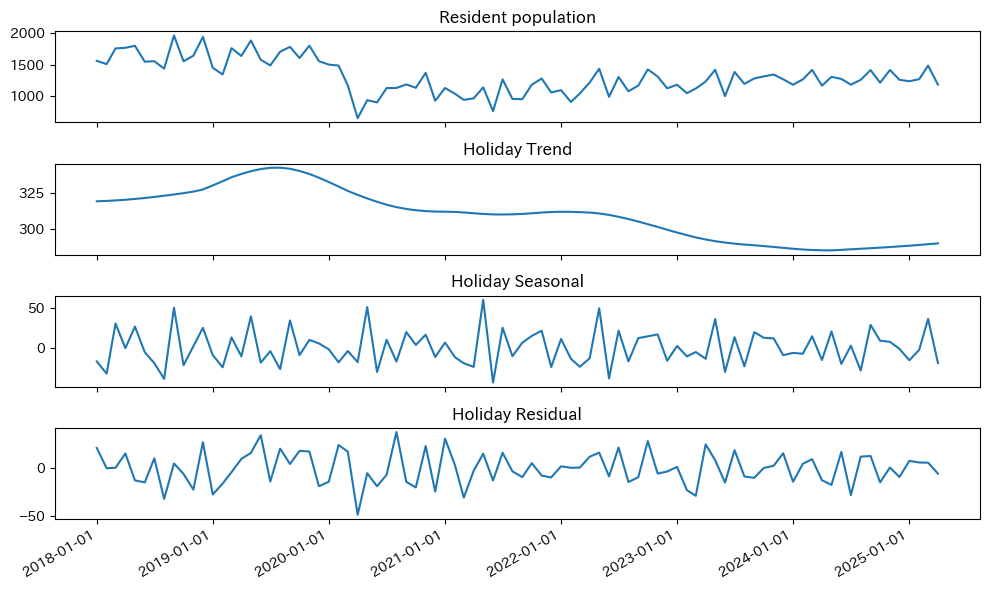

In [149]:
fig, axes = plt.subplots(ncols=1, nrows=4, figsize=(10, 6))

# 元のデータを表示
axes[0].plot(center_df['ds'], center_df['y']) # Explicitly use 'ds' for x-axis
axes[0].set_title('Resident population')

# トレンド成分のプロット
axes[1].plot(center_df['ds'], holiday_trend) # Explicitly use 'ds' for x-axis
axes[1].set_title('Holiday Trend')

# 季節成分のプロット
axes[2].plot(center_df['ds'], holiday_seasonal) # Explicitly use 'ds' for x-axis
axes[2].set_title('Holiday Seasonal')

# 残差成分のプロット
axes[3].plot(center_df['ds'], holiday_resid) # Explicitly use 'ds' for x-axis
axes[3].set_title('Holiday Residual')

# Set x-axis format
date_form = mdates.DateFormatter('%Y-%m-%d')
for ax in axes:
    ax.xaxis.set_major_formatter(date_form)
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

*   **トレンド成分**: 他の地域と比較して、全体的に滞在人口が最も高い水準で推移。岡山市の主要なハブとしての機能であることがわかる。2020年から2021年にかけてパンデミックの影響で減少傾向が見られる。直近では緩やかな下降、または横ばいの傾向。
*   **季節成分**: 特定の月や時期に人流が増加または減少する周期的な変動が確認できる。
*   **残差成分**: パンデミック発生時など、社会情勢の変化による大きな影響が見受けられる。

### 岡南地域のSTL分解

In [106]:
# STL分解を実行。まずはインスタンス化。
holiday_model = STL(
    kounan_df['y'], # 'y'カラムに対して分解を実行
    period=12            # 月次周期なら12
)

holiday_result = holiday_model.fit()
holiday_trend = holiday_result.trend
holiday_seasonal = holiday_result.seasonal
holiday_resid = holiday_result.resid

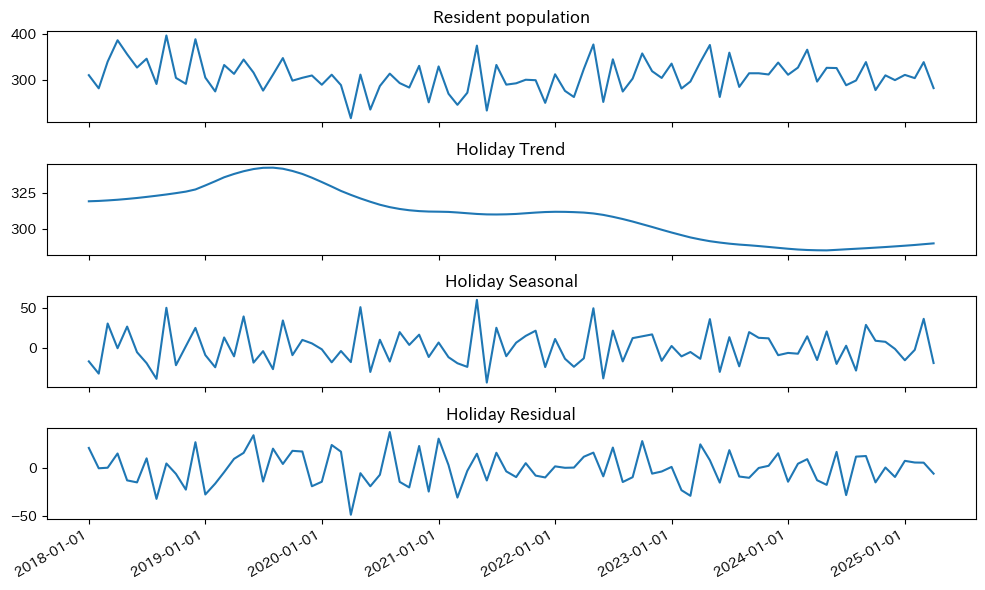

In [150]:
import matplotlib.dates as mdates # Add this import

fig, axes = plt.subplots(ncols=1, nrows=4, figsize=(10, 6))

# 元のデータを表示
axes[0].plot(kounan_df['ds'], kounan_df['y']) # Corrected and explicitly use 'ds' for x-axis
axes[0].set_title('Resident population')

# トレンド成分のプロット
axes[1].plot(kounan_df['ds'], holiday_trend) # Explicitly use 'ds' for x-axis
axes[1].set_title('Holiday Trend')

# 季節成分のプロット
axes[2].plot(kounan_df['ds'], holiday_seasonal) # Explicitly use 'ds' for x-axis
axes[2].set_title('Holiday Seasonal')

# 残差成分のプロット
axes[3].plot(kounan_df['ds'], holiday_resid) # Explicitly use 'ds' for x-axis
axes[3].set_title('Holiday Residual')

# Set x-axis format
date_form = mdates.DateFormatter('%Y-%m-%d')
for ax in axes:
    ax.xaxis.set_major_formatter(date_form)
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

*   **トレンド成分**: 過去には緩やかな上昇傾向が見られたが、直近では横ばい、あるいはごくわずかな下降傾向にあると見受けられる。岡南地域が郊外型商業地としての安定した人流を維持していると推察できる。
*   **季節成分**: 特定の月や時期に人流が増加または減少するパターンが毎年繰り返されていることが確認でき、季節的なイベントや長期休暇、気候などが人流に影響を与えている可能性が高い。
*   **残差成分**: 残差の変動幅は比較的安定しているが、時期によっては大きな変動が見られる。

### 西大寺地域のSTL分解

In [108]:
# STL分解を実行。まずはインスタンス化。
holiday_model = STL(
    saidaiji_df['y'], # 'y'カラムに対して分解を実行
    period=12            # 月次周期なら12
)

holiday_result = holiday_model.fit()
holiday_trend = holiday_result.trend
holiday_seasonal = holiday_result.seasonal
holiday_resid = holiday_result.resid

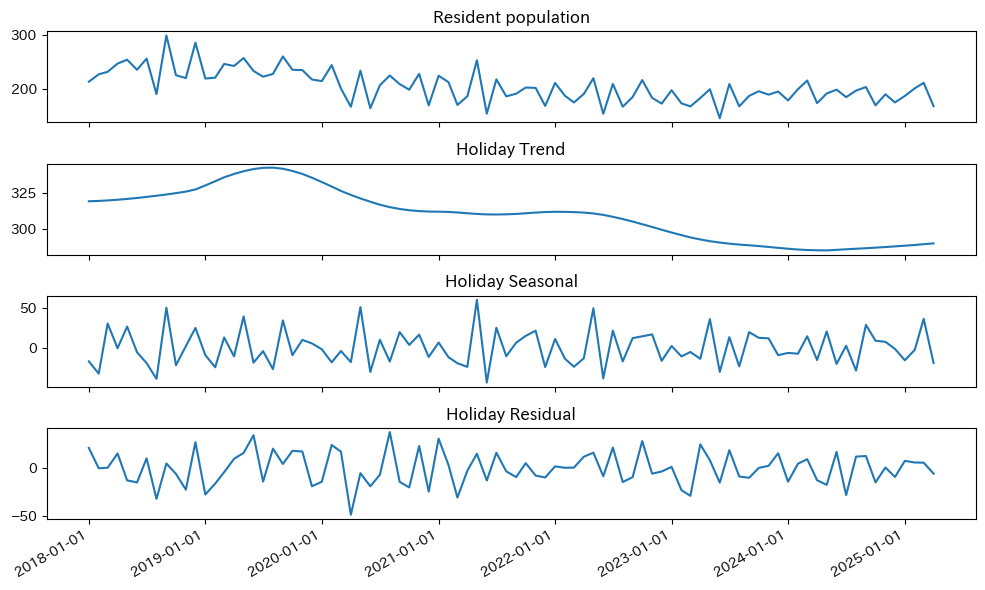

In [151]:
import matplotlib.dates as mdates # Add this import

fig, axes = plt.subplots(ncols=1, nrows=4, figsize=(10, 6))

# 元のデータを表示
axes[0].plot(saidaiji_df['ds'], saidaiji_df['y']) # Explicitly use 'ds' for x-axis
axes[0].set_title('Resident population')

# トレンド成分のプロット
axes[1].plot(saidaiji_df['ds'], holiday_trend) # Explicitly use 'ds' for x-axis
axes[1].set_title('Holiday Trend')

# 季節成分のプロット
axes[2].plot(saidaiji_df['ds'], holiday_seasonal) # Explicitly use 'ds' for x-axis
axes[2].set_title('Holiday Seasonal')

# 残差成分のプロット
axes[3].plot(saidaiji_df['ds'], holiday_resid) # Explicitly use 'ds' for x-axis
axes[3].set_title('Holiday Residual')

# Set x-axis format
date_form = mdates.DateFormatter('%Y-%m-%d')
for ax in axes:
    ax.xaxis.set_major_formatter(date_form)
fig.autofmt_xdate()

plt.tight_layout()
plt.show()


*   **トレンド成分**: コロナ禍による影響を見受けられる。近年は一定で推移している。
*   **季節成分**: 季節変動のパターンが他地域と比べて弱い。季節によらず、一定の人流があると見受けられる。
*   **残差成分**: 残差の変動幅は概ね小さいものの、一部の期間で大きな振れが見られる。

### 浜・原尾島地域のSTL分解

In [110]:
# STL分解を実行。まずはインスタンス化。
holiday_model = STL(
    hama_haraojima_df['y'], # 'y'カラムに対して分解を実行
    period=12            # 月次周期なら12
)

holiday_result = holiday_model.fit()
holiday_trend = holiday_result.trend
holiday_seasonal = holiday_result.seasonal
holiday_resid = holiday_result.resid

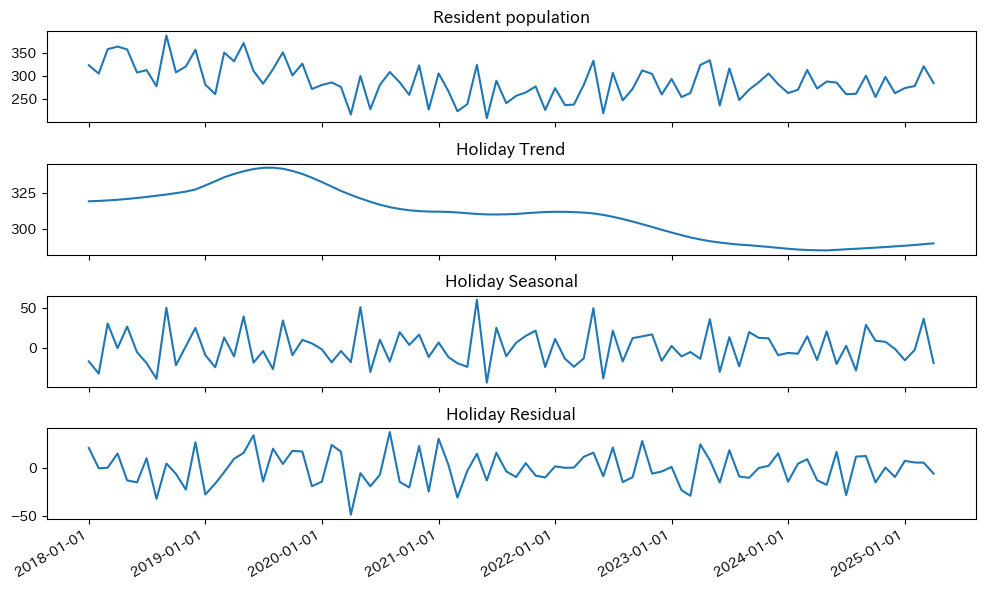

In [152]:
import matplotlib.dates as mdates # Add this import

fig, axes = plt.subplots(ncols=1, nrows=4, figsize=(10, 6))

# 元のデータを表示
axes[0].plot(hama_haraojima_df['ds'], hama_haraojima_df['y']) # Corrected and explicitly use 'ds' for x-axis
axes[0].set_title('Resident population')

# トレンド成分のプロット
axes[1].plot(hama_haraojima_df['ds'], holiday_trend) # Explicitly use 'ds' for x-axis
axes[1].set_title('Holiday Trend')

# 季節成分のプロット
axes[2].plot(hama_haraojima_df['ds'], holiday_seasonal) # Explicitly use 'ds' for x-axis
axes[2].set_title('Holiday Seasonal')

# 残差成分のプロット
axes[3].plot(hama_haraojima_df['ds'], holiday_resid) # Explicitly use 'ds' for x-axis
axes[3].set_title('Holiday Residual')

# Set x-axis format
date_form = mdates.DateFormatter('%Y-%m-%d')
for ax in axes:
    ax.xaxis.set_major_formatter(date_form);
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

*   **トレンド成分**: 他の地域と同様に、この地域もCOVID-19パンデミックの影響を受け、人流が一時的に減少した期間があったと見受けられる。しかし、近年は安定した推移の傾向が見られ、大きな下降や上昇トレンドは観察されない。
*   **季節成分**: 年間を通じて周期的な変動が観察される。特定の月や時期に人流が増加または減少するパターンが毎年繰り返されており、季節的なイベントや長期休暇、気候などが人流に影響を与えている可能性がある。
*   **残差成分**: 残差の変動幅は比較的安定しているものの、一部の期間で大きな振れが見られる。

### 北長瀬地域のSTL分解

In [112]:
# STL分解を実行。まずはインスタンス化。
holiday_model = STL(
    kitanagase_df['y'], # 'y'カラムに対して分解を実行
    period=12            # 月次周期なら12
)

holiday_result = holiday_model.fit()
holiday_trend = holiday_result.trend
holiday_seasonal = holiday_result.seasonal
holiday_resid = holiday_result.resid

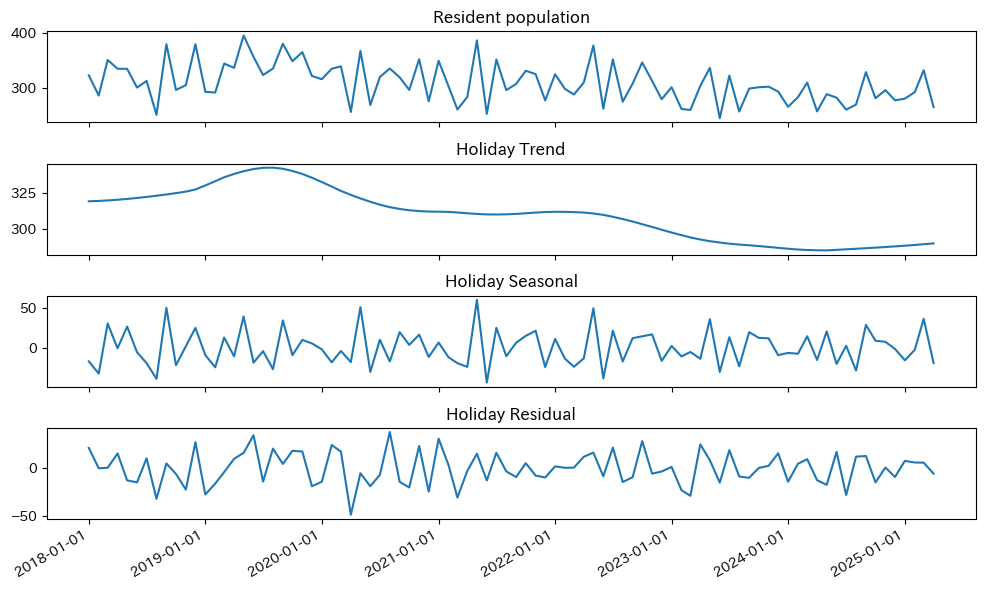

In [153]:
import matplotlib.dates as mdates # Add this import

fig, axes = plt.subplots(ncols=1, nrows=4, figsize=(10, 6))

# 元のデータを表示
axes[0].plot(kitanagase_df['ds'], kitanagase_df['y']) # Explicitly use 'ds' for x-axis
axes[0].set_title('Resident population')

# トレンド成分のプロット
axes[1].plot(kitanagase_df['ds'], holiday_trend) # Explicitly use 'ds' for x-axis
axes[1].set_title('Holiday Trend')

# 季節成分のプロット
axes[2].plot(kitanagase_df['ds'], holiday_seasonal) # Explicitly use 'ds' for x-axis
axes[2].set_title('Holiday Seasonal')

# 残差成分のプロット
axes[3].plot(kitanagase_df['ds'], holiday_resid) # Explicitly use 'ds' for x-axis
axes[3].set_title('Holiday Residual')

# Set x-axis format
date_form = mdates.DateFormatter('%Y-%m-%d')
for ax in axes:
    ax.xaxis.set_major_formatter(date_form)
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

*   **トレンド成分**: 分析期間を通じて人流が緩やかな減少傾向を示した。再開発による商業施設の集積や公共空間の整備が進んだ地域であるにもかかわらず、人流が顕著に増加しているわけではないことを示唆すると考える。住民の行動パターンの変化や、地域外からの流入が限定的である可能性も考えられる。
*   **季節成分**: 年間を通じて周期的な変動が観察される。
*   **残差成分**: 残差の変動幅は概ね安定しているものの、一部の期間で大きな振れが見られる。

### STL分解による各地域の結果考察


全ての地域でCOVID-19パンデミックによる人流への影響が見られたが、その後はそれぞれの地域の特性に応じた回復、または安定した推移を示している。中心市街地は突出して人流が多いが、他の地域はより生活圏に根差した安定した人流パターンを持つ傾向がある。

住宅街は比較的予測がし易いが、中心市街地のように、遊びに出かけたり、観光客の増減に左右される地域は予測にしにくい。

*   **中心市街地**: トレンド成分は最も高い水準で推移しており、主要なハブとしての機能が確認された。COVID-19パンデミックによる一時的な人流減少が見られたが、その後回復しつつあるものの、直近では緩やかな下降または横ばいの傾向を示している。明確な季節変動も存在した。
*   **岡南**: トレンド成分は過去の緩やかな上昇から、近年は横ばい、または微減傾向に転じている。郊外型商業地として安定した人流を推移していると考える。
*   **西大寺**: トレンド成分は比較的安定した推移を示した。季節変動は他地域に比べて弱い傾向にあった。地域拠点としての性格上、安定して推移していると考える。
*   **浜・原尾島**: トレンド成分はコロナ禍による減少後、安定した推移に転じている。住宅地としての性格が強く、日々の生活圏としての人流が定着していると考える。
*   **北長瀬**: トレンド成分は分析期間を通じて緩やかな減少傾向を示した。再開発による施設集積があるにもかかわらず、人流が顕著に増加していないことから、住民の行動パターンの変化や地域外からの流入の限定的であると考える。


## 時系列予測
Prophetモデルインスタンスを作成し、予測を実行

In [114]:
start_date = '2024-05-01'

### 中心市街地の時系列予測

In [115]:
# Prophetモデルインスタンスを作成し、休日のデータにフィット
holiday_model = Prophet(seasonality_mode='additive')

#学習期間を2024年4月まで
holiday_model.fit(center_df[center_df['ds'] <= start_date])


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [116]:
#学習済み予測モデルを利用して予測
#make_future_dataframeメソッドでperiodsパラメータに、予測期間として追加する行数を指定
center_holiday_future = holiday_model.make_future_dataframe(periods=12, freq='MS')


In [117]:
#予測を実行
center_holiday_forecast = holiday_model.predict(center_holiday_future)

filtered_forecast = center_holiday_forecast[center_holiday_forecast['ds'] >= start_date]
display(filtered_forecast[['ds', 'yhat']])


,ds,yhat
76,2024-05-01,1253.143113
77,2024-06-01,1070.574418
78,2024-07-01,1398.978904
79,2024-08-01,1206.688651
80,2024-09-01,1276.619067
81,2024-10-01,1320.887304
82,2024-11-01,1478.390701
83,2024-12-01,1179.185778
84,2025-01-01,1259.318373
85,2025-02-01,1175.721372


In [118]:
# 予測の実施（全期間）
center_df_future = holiday_model.make_future_dataframe(periods=12,
                                    freq='M')
center_df_pred = holiday_model.predict(center_df_future)
# 元のデータセットに予測値を結合
center_df['Predict'] = center_df_pred['yhat']


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


In [119]:
#予測値
train_pred = center_df.iloc[:-12].loc[:, 'Predict']
test_pred = center_df.iloc[-12:].loc[:, 'Predict']

#実測値
y_test = center_df.iloc[-12:].loc[:, 'y']

# 精度指標
print('MAPE:')
print(mean_absolute_percentage_error(y_test, test_pred))

MAPE:
0.10385113022282522


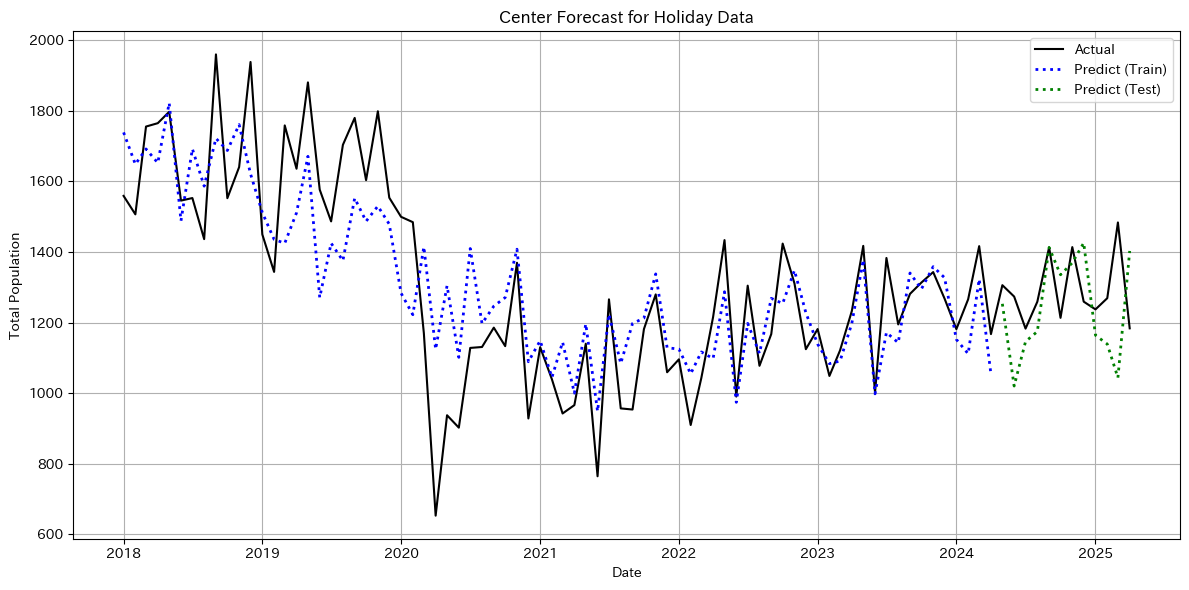

In [120]:
# グラフ化
fig, ax = plt.subplots(figsize=(12, 6))

# 実際の値（全期間）
ax.plot(center_df['ds'], center_df['y'], label="Actual", color="black")

# '2024-04-01'までの予測値
ax.plot(center_df['ds'].iloc[:-12], train_pred, linestyle="dotted", lw=2, color="blue", label="Predict (Train)")

# '2024-05-01'から '2025-04-01'までの予測値
ax.plot(center_df['ds'].iloc[-12:], test_pred, linestyle="dotted", lw=2, color="green", label="Predict (Test)")

plt.title('Center Forecast for Holiday Data')
plt.xlabel('Date')
plt.ylabel('Total Population')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

*   **学習期間とテスト期間の傾向**: 学習期間 `Predict (Train)` とテスト期間 `Predict (Test)` で、実際の値の傾向に違いが見受けられる。特にテスト期間において、モデルが実際の変動に追いついていない箇所がある。これは、予測期間中に過去のデータにはない新たなトレンドやイベントが発生した可能性があると考える。

*   **MAPE**: 11.46%

### 岡南地域の時系列予測

In [121]:
# 新しいProphetモデルインスタンスを作成し、休日のデータにフィット
holiday_model = Prophet(seasonality_mode='additive')

#学習期間を2024年4月まで
holiday_model.fit(kounan_df[kounan_df['ds'] <= start_date])

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [122]:
#学習済み予測モデルを利用して予測
#make_future_dataframeメソッドでperiodsパラメータに、予測期間として追加する行数を指定
kounan_holiday_future = holiday_model.make_future_dataframe(periods=12, freq='MS')


In [123]:
#予測を実行
kounan_holiday_forecast = holiday_model.predict(kounan_holiday_future)

#出力された予測値や、不確実性区間を確認
filtered_forecast = kounan_holiday_forecast[kounan_holiday_forecast['ds'] >= start_date]
display(filtered_forecast[['ds', 'yhat']])

,ds,yhat
76,2024-05-01,359.337996
77,2024-06-01,274.563094
78,2024-07-01,345.654967
79,2024-08-01,330.951282
80,2024-09-01,320.687183
81,2024-10-01,317.958343
82,2024-11-01,343.144887
83,2024-12-01,281.813074
84,2025-01-01,351.631522
85,2025-02-01,297.250911


In [124]:
# 予測の実施（全期間）
kounan_df_future = holiday_model.make_future_dataframe(periods=12,
                                    freq='M')
kounan_df_pred = holiday_model.predict(kounan_df_future)
# 元のデータセットに予測値を結合
kounan_df['Predict'] = kounan_df_pred['yhat']


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


In [125]:
#予測値
train_pred = kounan_df.iloc[:-12].loc[:, 'Predict']
test_pred = kounan_df.iloc[-12:].loc[:, 'Predict']

#実測値
y_test = kounan_df.iloc[-12:].loc[:, 'y']

# 精度指標
print('MAPE:')
print(mean_absolute_percentage_error(y_test, test_pred))

MAPE:
0.1259304888489049


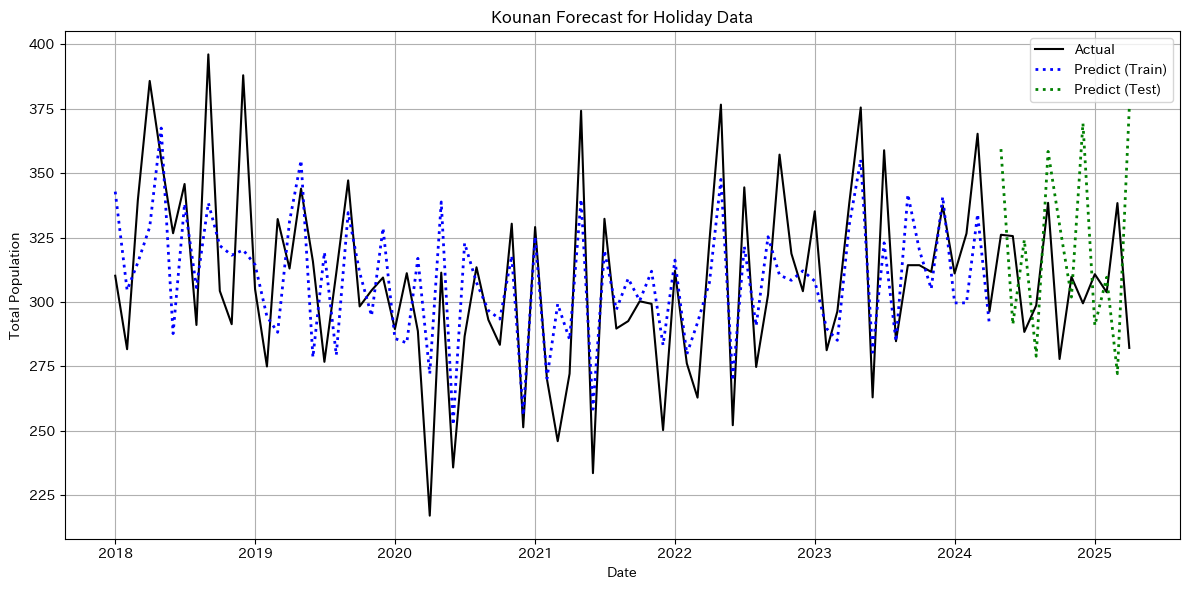

In [126]:
# グラフ化
fig, ax = plt.subplots(figsize=(12, 6))

# 実際の値（全期間）
ax.plot(kounan_df['ds'], kounan_df['y'], label="Actual", color="black")

# '2024-04-01'までの予測値
ax.plot(kounan_df['ds'].iloc[:-12], train_pred, linestyle="dotted", lw=2, color="blue", label="Predict (Train)")

# '2024-05-01'から '2025-04-01'までの予測値
ax.plot(kounan_df['ds'].iloc[-12:], test_pred, linestyle="dotted", lw=2, color="green", label="Predict (Test)")

plt.title('Kounan Forecast for Holiday Data')
plt.xlabel('Date')
plt.ylabel('Total Population')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

*   **人流の安定性**: 2021年～2023年にかけて、実績値（Actual）は、比較的安定した推移を示しているが、2024年以降、傾向に変化が見られる。

*    **MAPE**: 12.76%

### 西大寺地域の時系列予測

In [127]:
# 新しいProphetモデルインスタンスを作成し、休日のデータにフィット
holiday_model = Prophet(seasonality_mode='additive')

#学習期間を2024年4月まで
holiday_model.fit(saidaiji_df[saidaiji_df['ds'] <= start_date])

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [128]:
#学習済み予測モデルを利用して予測
#make_future_dataframeメソッドでperiodsパラメータに、予測期間として追加する行数を指定
saidaiji_holiday_future = holiday_model.make_future_dataframe(periods=12, freq='MS')


In [129]:
#予測を実行
saidaiji_holiday_forecast = holiday_model.predict(saidaiji_holiday_future)

#出力された予測値や、不確実性区間を確認
filtered_forecast = saidaiji_holiday_forecast[saidaiji_holiday_forecast['ds'] >= start_date]
display(filtered_forecast[['ds', 'yhat']])

,ds,yhat
76,2024-05-01,206.149205
77,2024-06-01,132.529152
78,2024-07-01,187.165171
79,2024-08-01,178.538670
80,2024-09-01,178.037292
81,2024-10-01,172.844800
82,2024-11-01,188.251169
83,2024-12-01,144.930847
84,2025-01-01,182.155039
85,2025-02-01,164.527663


In [130]:
# 予測の実施（全期間）
saidaiji_df_future = holiday_model.make_future_dataframe(periods=12,
                                    freq='M')
saidaiji_df_pred = holiday_model.predict(saidaiji_df_future)
# 元のデータセットに予測値を結合
saidaiji_df['Predict'] = saidaiji_df_pred['yhat']


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


In [131]:
#予測値
train_pred = saidaiji_df.iloc[:-12].loc[:, 'Predict']
test_pred = saidaiji_df.iloc[-12:].loc[:, 'Predict']

#実測値
y_test = saidaiji_df.iloc[-12:].loc[:, 'y']

# 精度指標
print('MAPE:')
print(mean_absolute_percentage_error(y_test, test_pred))

MAPE:
0.14390851129822865


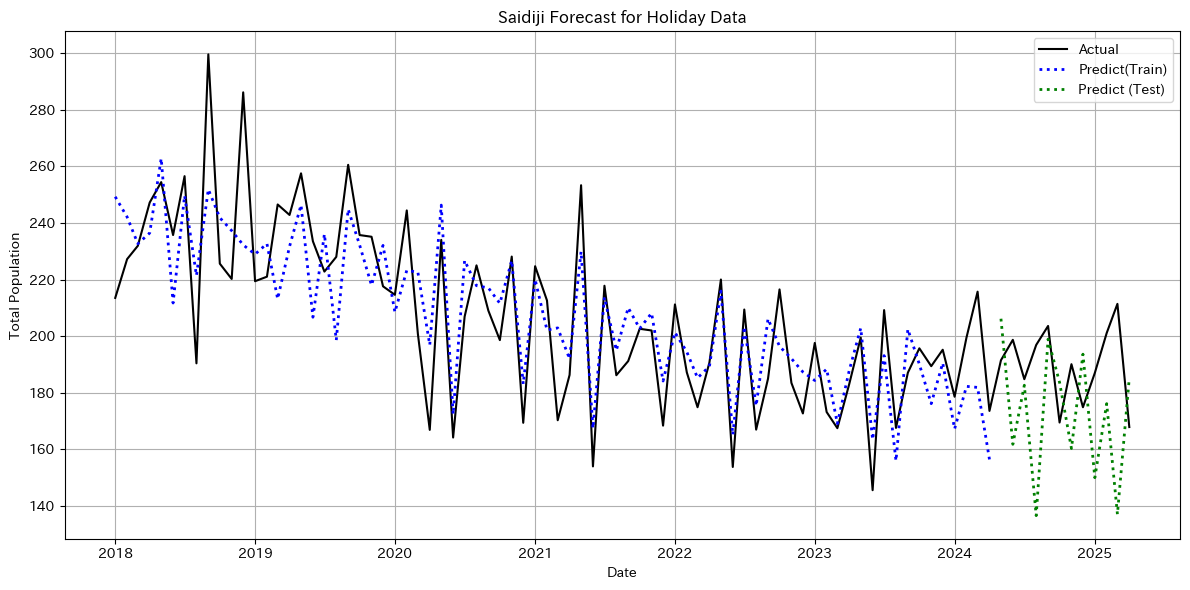

In [132]:
# グラフ化
fig, ax = plt.subplots(figsize=(12, 6))

# 実際の値（全期間）
ax.plot(saidaiji_df['ds'], saidaiji_df['y'], label="Actual", color="black")

# '2024-04-01'までの予測値
ax.plot(saidaiji_df['ds'].iloc[:-12], train_pred, linestyle="dotted", lw=2, color="blue", label="Predict(Train)")

# '2024-05-01'から '2025-04-01'までの予測値
ax.plot(saidaiji_df['ds'].iloc[-12:], test_pred, linestyle="dotted", lw=2, color="green", label="Predict (Test)")

plt.title('Saidiji Forecast for Holiday Data')
plt.xlabel('Date')
plt.ylabel('Total Population')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

*   **実際の値と予測値の乖離**: プロットを見ると、予測線（Predict）は実際の値（Actual）の全体的なトレンドと季節性を追従している。しかし、テスト期間 `Predict (Test)` において、実測値上昇に対して予測が追いついていない箇所がある。これは、モデルが過去のデータにはない新たな増加トレンドの可能性がある。

*    **MAPE**: 13.35%

### 浜・原尾島地域の時系列予測

In [133]:
# 新しいProphetモデルインスタンスを作成し、休日のデータにフィット
holiday_model = Prophet(seasonality_mode='additive')

#学習期間を2024年4月まで
holiday_model.fit(hama_haraojima_df[hama_haraojima_df['ds'] <= start_date])


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [134]:
#学習済み予測モデルを利用して予測
#make_future_dataframeメソッドでperiodsパラメータに、予測期間として追加する行数を指定
hama_haraojima_holiday_future = holiday_model.make_future_dataframe(periods=12, freq='MS')


In [135]:
#予測を実行
hama_haraojima_holiday_forecast = holiday_model.predict(hama_haraojima_holiday_future)

#出力された予測値や、不確実性区間を確認
filtered_forecast = hama_haraojima_holiday_forecast[hama_haraojima_holiday_forecast['ds'] >= start_date]
display(filtered_forecast[['ds', 'yhat']])

,ds,yhat
76,2024-05-01,315.834841
77,2024-06-01,242.257047
78,2024-07-01,307.953631
79,2024-08-01,294.995196
80,2024-09-01,289.086764
81,2024-10-01,270.625126
82,2024-11-01,311.678975
83,2024-12-01,242.329499
84,2025-01-01,308.074312
85,2025-02-01,274.021195


In [136]:
# 予測の実施（全期間）
hama_haraojima_df_future = holiday_model.make_future_dataframe(periods=12,
                                    freq='M')
hama_haraojima_df_pred = holiday_model.predict(hama_haraojima_df_future)
# 元のデータセットに予測値を結合
hama_haraojima_df['Predict'] = hama_haraojima_df_pred['yhat']


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


In [137]:
#予測値
train_pred = hama_haraojima_df.iloc[:-12].loc[:, 'Predict']
test_pred = hama_haraojima_df.iloc[-12:].loc[:, 'Predict']

#実測値
y_test = hama_haraojima_df.iloc[-12:].loc[:, 'y']

# 精度指標
print('MAPE:')
print(mean_absolute_percentage_error(y_test, test_pred))

MAPE:
0.11387716994765207


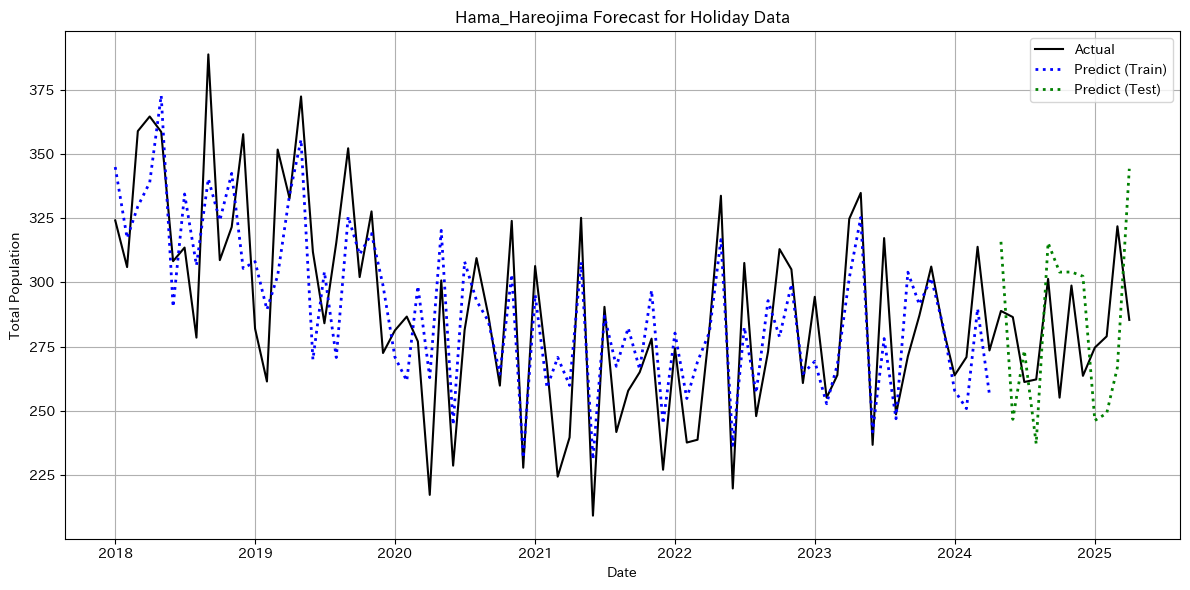

In [138]:
# グラフ化
fig, ax = plt.subplots(figsize=(12, 6))

# 実際の値（全期間）
ax.plot(hama_haraojima_df['ds'], hama_haraojima_df['y'], label="Actual", color="black")

# '2024-04-01'までの予測値
ax.plot(hama_haraojima_df['ds'].iloc[:-12], train_pred, linestyle="dotted", lw=2, color="blue", label="Predict (Train)")

# '2024-05-01'から '2025-04-01'までの予測値
ax.plot(hama_haraojima_df['ds'].iloc[-12:], test_pred, linestyle="dotted", lw=2, color="green", label="Predict (Test)")

plt.title('Hama_Hareojima Forecast for Holiday Data')
plt.xlabel('Date')
plt.ylabel('Total Population')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

*   **実績値と予測値の整合性**: プロットされた実際の値（Actual）と予測線（Predict）は、全体的なトレンドと季節性において類似した動きを示しているが、テスト期間 `Predict（Test）` は過去のトレンドから変化があったと考える。

*    **MAPE**: 12.11%

### 北長瀬地域の時系列予測

In [139]:
# 新しいProphetモデルインスタンスを作成し、休日のデータにフィット
holiday_model = Prophet(seasonality_mode='additive')

#学習期間を2024年4月まで
holiday_model.fit(kitanagase_df[kitanagase_df['ds'] <= start_date])


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [140]:
#学習済み予測モデルを利用して予測
#make_future_dataframeメソッドでperiodsパラメータに、予測期間として追加する行数を指定
kitanagase_holiday_future = holiday_model.make_future_dataframe(periods=12, freq='MS')


In [141]:
#予測を実行
kitanagase_holiday_forecast = holiday_model.predict(kitanagase_holiday_future)

#出力された予測値や、不確実性区間を確認
filtered_forecast = kitanagase_holiday_forecast[kitanagase_holiday_forecast['ds'] >= start_date]
display(filtered_forecast[['ds', 'yhat']])

,ds,yhat
76,2024-05-01,331.164879
77,2024-06-01,242.067635
78,2024-07-01,318.174141
79,2024-08-01,293.905506
80,2024-09-01,291.204702
81,2024-10-01,280.906099
82,2024-11-01,307.664053
83,2024-12-01,250.850882
84,2025-01-01,308.584152
85,2025-02-01,259.116233


In [142]:
# 予測の実施（全期間）
kitanagase_df_future = holiday_model.make_future_dataframe(periods=12,
                                    freq='M')
kitanagase_df_pred = holiday_model.predict(kitanagase_df_future)
# 元のデータセットに予測値を結合
kitanagase_df['Predict'] = kitanagase_df_pred['yhat']


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


In [143]:
#予測値
train_pred = kitanagase_df.iloc[:-12].loc[:, 'Predict']
test_pred = kitanagase_df.iloc[-12:].loc[:, 'Predict']

#実測値
y_test = kitanagase_df.iloc[-12:].loc[:, 'y']

# 精度指標
print('MAPE:')
print(mean_absolute_percentage_error(y_test, test_pred))

MAPE:
0.11323328232474851


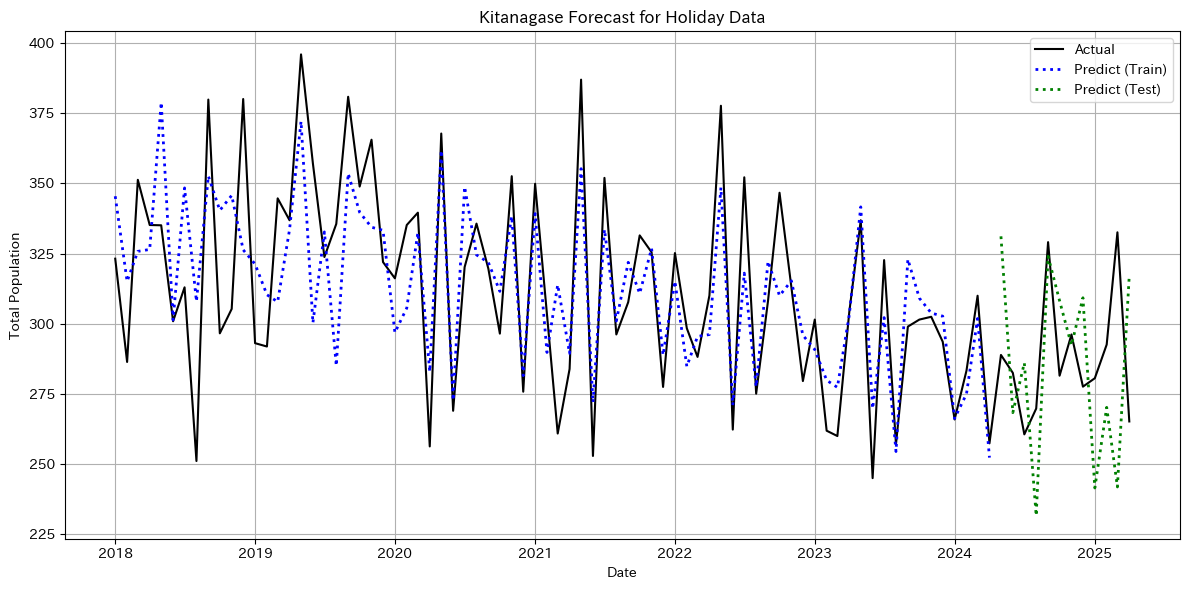

In [144]:
# グラフ化
fig, ax = plt.subplots(figsize=(12, 6))

# 実際の値（全期間）
ax.plot(kitanagase_df['ds'], kitanagase_df['y'], label="Actual", color="black")

# '2024-04-01'までの予測値
ax.plot(kitanagase_df['ds'].iloc[:-12], train_pred, linestyle="dotted", lw=2, color="blue", label="Predict (Train)")

# '2024-05-01'から '2025-04-01'までの予測値
ax.plot(kitanagase_df['ds'].iloc[-12:], test_pred, linestyle="dotted", lw=2, color="green", label="Predict (Test)")

plt.title('Kitanagase Forecast for Holiday Data')
plt.xlabel('Date')
plt.ylabel('Total Population')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

*   **実際の値と予測値の乖離**: 実際の値と予測値は全体的に似たトレンドを示しているが、一部で乖離が見られる。例えば、2023年までは毎年5月頃に増加傾向が見られたが、2024年以降は減少傾向にあるなど、過去のパターンが変化している部分でモデルが追従しきれていない可能性が考えられる。

*    **MAPE**: 10.86%

### Prophetモデルによる各地域の時系列予測の結果考察


*   **休日の予測の課題**: 休日の人流データは予測がやや難しい傾向にあることが全ての地域で共通して観察された。休日のMAPE値は（北長瀬: 10.86%, 中心市街地: 11.46%, 浜・原尾島: 12.11%, 岡南: 12.76%, 西大寺: 13.35%）といずれもやや高い精度にかける傾向だった。これは、休日特有の不規則なイベントや社会情勢の変化が人流に与える影響が大きいためだと考えられる。

*   **実績との乖離**: パンデミックのような急激な社会情勢の変化が発生した時期や、過去のトレンドから逸脱するような新たな人流パターンが生じた場合、モデルの予測が実績に追従しきれていない箇所が見受けられた。過去のデータに基づいてトレンドや季節性を学習するため、傾向の変化が反映されなかった為である。

*   **今後の改善点**: 予測精度をさらに向上させるためには、外部要因（祝日、特定のイベント、気象データなど）を考慮したモデルの改善ができると良いだろう。

# 仮説に対する考察

*   **仮説1: 中心部は商業・業務機能の集中により、滞在人口が多い。**
    *   **考察**: STL分解のトレンド成分が最も高い水準で推移していた為、中心市街地が岡山市の主要なハブとして機能していると確認できた。

*   **仮説2: 岡南は郊外型商業地として、滞在人口が一定で推移する。**
    *   **考察**: トレンド成分は過去の緩やかな上昇から、近年は横ばい、または微減傾向に転じている。これは「一定で推移する」という仮説と概ね合致する。郊外型商業地として安定した人流を維持していると判断できる。

*   **仮説3: 西大寺は周辺を住宅地が囲む地域拠点である特徴から滞在人口が一定で推移する。**
    *   **考察**: トレンド成分が比較的安定した推移を示していた。季節変動が他地域に比べて弱い傾向にあったことも、地域拠点として季節によらず一定の人流があるという特徴と整合する。

*   **仮説4: 原・原尾島は住宅地としての性格が強く、人流の変動が比較的小さい。**
    *   **考察**: トレンド成分がコロナ禍による減少後、安定した推移に転じていた。住宅地としての性格が強く、日々の生活圏としての人流が定着しており、比較的変動が小さい傾向が見られた。

*   **仮説5: 北長瀬は近年の再開発および商業施設の集積により、人流が増加傾向。**
    *   **考察**: STL分解のトレンド成分は分析期間を通じて緩やかな減少傾向を示しており、この仮説は支持されなかった。再開発による施設集積があるにもかかわらず人流が顕著に増加していないことは、住民の行動パターンの変化や地域外からの流入が限定的である可能性、あるいは地域内で行動が完結している可能性を示唆している。増加傾向というよりは、安定、あるいは微減傾向にあると言える。

# 出典
* 出典: 「人流データのオープンデータについて」（岡山市）（https://www.city.okayama.jp/shisei/0000031965.html）
* 「人流データのオープンデータについて」（岡山市）（https://www.city.okayama.jp/shisei/0000031965.html） を加工して作成